In [244]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp
from scipy.stats import randint, uniform

# 머신러닝 
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error, mean_absolute_error, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, balanced_accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier, LGBMRegressor


# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [245]:
df = pd.read_csv('data/merged_final_data.csv')

In [246]:
cols = df.columns
cols 

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'category', 'seller_city',
       'seller_state', 'order_purchase_dayofweek', 'order_purchase_month',
       'approved_days', 'dispatch_days', 'delivery_days',
       'expected_delivery_days', 'delay_days', 'delay_days_int', 'is_delayed',
       'delay_days_cat', 'main_category', 'sub_category', 'distance_km',
       'distance_cat', 'cross_state'],
      dtype='str')

In [247]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  109294 non-null  str    
 1   customer_id               109294 non-null  str    
 2   customer_unique_id        109294 non-null  str    
 3   customer_city             109294 non-null  str    
 4   customer_state            109294 non-null  str    
 5   order_item_id             109294 non-null  int64  
 6   seller_id                 109294 non-null  str    
 7   shipping_limit_date       109294 non-null  str    
 8   price                     109294 non-null  float64
 9   freight_value             109294 non-null  float64
 10  review_score              109294 non-null  int64  
 11  category                  107749 non-null  str    
 12  seller_city               109294 non-null  str    
 13  seller_state              109294 non-null  str    
 14 

In [248]:
df.isna().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_item_id                  0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
review_score                   0
category                    1545
seller_city                    0
seller_state                   0
order_purchase_dayofweek       0
order_purchase_month           0
approved_days                  0
dispatch_days                  0
delivery_days                  0
expected_delivery_days         0
delay_days                     0
delay_days_int                 0
is_delayed                     0
delay_days_cat                 0
main_category                  0
sub_category                   0
distance_km                    0
distance_cat                   0
cross_state                    0
dtype: int64

### 머신러닝 모델 생성시 절대 안쓸만한 컬럼 제거

In [249]:
cols_to_drop = ['order_id','customer_id','seller_id','category','delay_days_int']
df = df.drop(columns=cols_to_drop)
df['delay_days'] = df['delay_days'].astype(int) # delay_days 정수화

In [250]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_unique_id        109294 non-null  str    
 1   customer_city             109294 non-null  str    
 2   customer_state            109294 non-null  str    
 3   order_item_id             109294 non-null  int64  
 4   shipping_limit_date       109294 non-null  str    
 5   price                     109294 non-null  float64
 6   freight_value             109294 non-null  float64
 7   review_score              109294 non-null  int64  
 8   seller_city               109294 non-null  str    
 9   seller_state              109294 non-null  str    
 10  order_purchase_dayofweek  109294 non-null  str    
 11  order_purchase_month      109294 non-null  int64  
 12  approved_days             109294 non-null  int64  
 13  dispatch_days             109294 non-null  int64  
 14 

In [251]:
df.isna().sum()

customer_unique_id          0
customer_city               0
customer_state              0
order_item_id               0
shipping_limit_date         0
price                       0
freight_value               0
review_score                0
seller_city                 0
seller_state                0
order_purchase_dayofweek    0
order_purchase_month        0
approved_days               0
dispatch_days               0
delivery_days               0
expected_delivery_days      0
delay_days                  0
is_delayed                  0
delay_days_cat              0
main_category               0
sub_category                0
distance_km                 0
distance_cat                0
cross_state                 0
dtype: int64

In [252]:
df.to_csv('./data/ml_data.csv')

In [253]:
df2 = df.copy()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_unique_id        109294 non-null  str    
 1   customer_city             109294 non-null  str    
 2   customer_state            109294 non-null  str    
 3   order_item_id             109294 non-null  int64  
 4   shipping_limit_date       109294 non-null  str    
 5   price                     109294 non-null  float64
 6   freight_value             109294 non-null  float64
 7   review_score              109294 non-null  int64  
 8   seller_city               109294 non-null  str    
 9   seller_state              109294 non-null  str    
 10  order_purchase_dayofweek  109294 non-null  str    
 11  order_purchase_month      109294 non-null  int64  
 12  approved_days             109294 non-null  int64  
 13  dispatch_days             109294 non-null  int64  
 14 

In [254]:
# feature engineering

df2 = df.copy()

# 베송속도 관련 파생피처들
df2['delivery_speed'] = df2['distance_km'] / df2['delivery_days']
df2['day_per_km'] = df2['delivery_days'] / df2['distance_km']
df2['delivery_ratio'] = df2['delivery_days'] / df2['expected_delivery_days']

# 가격 대비 배송비
df2['freight_ratio'] = df2['freight_value'] / df2['price']

# delivery_days * distance_km
df2["delivery_distance"] = df2["delivery_days"] * df2["distance_km"]

# delivery_days * price
df2["delivery_price"] = (df2["delivery_days"] * df2["price"])

# price + freight_value
df2['total_price'] = df2['price'] + df2['freight_value']

df2 = df2.replace([np.inf, -np.inf], np.nan)
num_cols = df2.select_dtypes(include=[np.number]).columns
df2[num_cols] = df2[num_cols].fillna(0)

In [255]:
df2.isna().sum()

customer_unique_id          0
customer_city               0
customer_state              0
order_item_id               0
shipping_limit_date         0
price                       0
freight_value               0
review_score                0
seller_city                 0
seller_state                0
order_purchase_dayofweek    0
order_purchase_month        0
approved_days               0
dispatch_days               0
delivery_days               0
expected_delivery_days      0
delay_days                  0
is_delayed                  0
delay_days_cat              0
main_category               0
sub_category                0
distance_km                 0
distance_cat                0
cross_state                 0
delivery_speed              0
day_per_km                  0
delivery_ratio              0
freight_ratio               0
delivery_distance           0
delivery_price              0
total_price                 0
dtype: int64

In [256]:
# 상파울루 고객 여부 (True/False를 1/0으로 변환)
df2['is_sp_customer'] = (df2['customer_state'] == 'SP').astype(int)

# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선)
df2['sp_route_type'] = 0

# 조건 1: 한 쪽이라도 SP인 경우 (부분적 인프라 혜택)
cond_partial = (df2['seller_state'] == 'SP') | (df2['customer_state'] == 'SP')
df2.loc[cond_partial, 'sp_route_type'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal, 'sp_route_type'] = 2

In [257]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_unique_id        109294 non-null  str    
 1   customer_city             109294 non-null  str    
 2   customer_state            109294 non-null  str    
 3   order_item_id             109294 non-null  int64  
 4   shipping_limit_date       109294 non-null  str    
 5   price                     109294 non-null  float64
 6   freight_value             109294 non-null  float64
 7   review_score              109294 non-null  int64  
 8   seller_city               109294 non-null  str    
 9   seller_state              109294 non-null  str    
 10  order_purchase_dayofweek  109294 non-null  str    
 11  order_purchase_month      109294 non-null  int64  
 12  approved_days             109294 non-null  int64  
 13  dispatch_days             109294 non-null  int64  
 14 

In [258]:
### 상파울루인지 구분하는 컬럼
# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선)
df2['sp_route_type'] = 0

# 조건 1: 한 쪽이라도 SP인 경우 (부분적 인프라 혜택)
cond_partial = (df2['seller_state'] == 'SP') | (df2['customer_state'] == 'SP')
df2.loc[cond_partial, 'sp_route_type'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal, 'sp_route_type'] = 2



### 상파울루 고객 여부 (True/False를 1/0으로 변환)
df2['is_sp_customer'] = (df2['customer_state'] == 'SP').astype(int)

# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선 및 고객이 SP가 아닌 경우)
df2['sp_route_type_customer'] = 0

# 조건 1: 고객이 SP인 경우 (부분적 인프라 혜택)
cond_partial = (df2['customer_state'] == 'SP')
df2.loc[cond_partial, 'sp_route_type_customer'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal, 'sp_route_type_customer'] = 2

# 결과 확인
print(df2['sp_route_type_customer'].value_counts().sort_index())



### 상파울루 셀러 여부 (True/False를 1/0으로 변환)
df2['is_sp_seller'] = (df2['seller_state'] == 'SP').astype(int)

# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선 및 셀러가 SP가 아닌 경우)
df2['sp_route_type_seller'] = 0

# 조건 1: 셀러가 SP인 경우 (부분적 인프라 혜택)
cond_partial_seller = (df2['seller_state'] == 'SP')
df2.loc[cond_partial_seller, 'sp_route_type_seller'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal_seller = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal_seller, 'sp_route_type_seller'] = 2

# 결과 확인
print(df2['sp_route_type_seller'].value_counts().sort_index())

sp_route_type_customer
0    63171
1    10959
2    35164
Name: count, dtype: int64
sp_route_type_seller
0    31348
1    42782
2    35164
Name: count, dtype: int64


# 분류모델

### 긍정 부정 그룹화 
#### NPS 기준 참고

In [259]:
# 분류모델 시 그룹화 함수 정의
def group_score(score):
    if score >= 4: return 1   # 긍정
    else: return 0            # 부정

X = df2.drop(columns=['review_score','customer_unique_id','customer_city','customer_state',
                      'shipping_limit_date','seller_city','seller_state'])
# X = df2.drop(columns=['review_score','customer_unique_id', 'customer_city', 'seller_city', 'shipping_limit_date'])
y = df2['review_score'].apply(group_score)

In [260]:
# 1. 원본 데이터 상태에서 분리 (원핫 인코딩 수행 전)
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, random_state=42, stratify=y_train_valid
)

# 2. 수치형/범주형 컬럼 분리
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

# 3. 전처리 파이프라인 정의
numeric_transformer = SimpleImputer(strategy='median') # 수치형은 중앙값으로 결측치 대체
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # 범주형은 최빈값으로 대체
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # 새로운 범주 등장 시 무시
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

### 1번째 분류모델: LightGBMClassifier

In [261]:
# 4. 최종 모델 파이프라인 구축
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=800,
        learning_rate=0.0587,
        num_leaves=39,
        max_depth=6,
        colsample_bytree=0.5186,
        min_child_samples=31,
        class_weight='balanced',
        random_state=42, 
        verbose=-1
    ))
])

# 5. 파이프라인 학습 (내부적으로 X_train만 전처리 규칙을 학습)
lgbm_pipeline.fit(X_train, y_train)

# 예측 시에는 파이프라인이 자동으로 X_valid를 변환 후 예측함
valid_proba_lgbm = lgbm_pipeline.predict_proba(X_valid)[:, 1]

In [262]:
# # 마지막 lightGBM 하이퍼파라미터 튜닝

# # LightGBM 탐색 공간
# lgbm_expanded_param = {
#     'classifier__n_estimators': [300, 500, 800],          # 트리 개수를 극단적으로 높임
#     'classifier__learning_rate': uniform(0.01, 0.05),   # 트리 개수가 많으므로 학습률은 낮춤
#     'classifier__num_leaves': randint(20, 50),        # 복잡도 조절의 핵심 (기본값 31)
#     'classifier__max_depth': [4, 5, 6, 7, 8],          # 트리 깊이 제한
#     'classifier__min_child_samples': randint(20, 50), # 과적합 방지를 위한 최소 샘플 수
#     'classifier__colsample_bytree': uniform(0.5, 0.4)  # 0.5 ~ 0.9 사이 피처 샘플링 비율
# }

# lgbm_random_search = RandomizedSearchCV(
#     estimator=lgbm_pipeline, # 파이프라인 내 LightGBM (verbose=-1 유지)
#     param_distributions=lgbm_expanded_param,
#     n_iter=20,           # 20번만 탐색
#     cv=3,
#     scoring='f1_macro',
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# lgbm_random_search.fit(X_train, y_train)

# # 결과 확인
# print("Best Parameters:", lgbm_random_search.best_params_)
# print("Best Macro F1 Score:", lgbm_random_search.best_score_)
# # Fitting 3 folds for each of 30 candidates, totalling 90 fits
# # Best Parameters: {'classifier__colsample_bytree': np.float64(0.5186662652854461), 'classifier__learning_rate': np.float64(0.058687775942072966), 'classifier__max_depth': 6, 'classifier__min_child_samples': 31, 'classifier__n_estimators': 800, 'classifier__num_leaves': 39}
# # Best Macro F1 Score: 0.6453960900982749

In [263]:
# threshold 평가 함수
def evaluate_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)

    neg_recall = recall_score(y_true, pred, pos_label=0)
    macro_f1 = f1_score(y_true, pred, average="macro")
    weighted_f1 = f1_score(y_true, pred, average="weighted")
    acc = accuracy_score(y_true, pred)
    bal_acc = balanced_accuracy_score(y_true, pred)


    return {
        "threshold": threshold,
        "neg_recall": neg_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": acc,
        "balanced_acc": bal_acc,
        "tn": cm[0,0],
        "fp": cm[0,1],
        "fn": cm[1,0],
        "tp": cm[1,1],
    }


# 0.01씩 threshold 바꿔가며 비교
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for th in thresholds:
    row = evaluate_threshold(y_valid, valid_proba_lgbm, th)
    results.append(row)

threshold_df = pd.DataFrame(results)

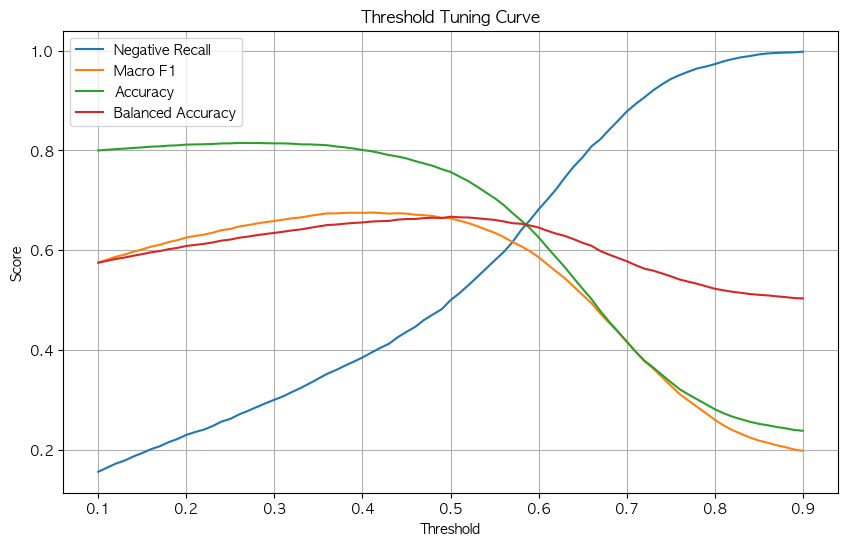

In [264]:
# 시각화

plt.figure(figsize=(10, 6))

plt.plot(threshold_df["threshold"], threshold_df["neg_recall"], label="Negative Recall")
plt.plot(threshold_df["threshold"], threshold_df["macro_f1"], label="Macro F1")
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["balanced_acc"], label="Balanced Accuracy")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [265]:
# neg_recall과 balanced_acc 차이
threshold_df["gap"] = (threshold_df["neg_recall"] - threshold_df["balanced_acc"]).abs()

# 두 값이 가장 가까운 threshold
best_row = threshold_df.loc[threshold_df["gap"].idxmin()]
best_threshold = best_row["threshold"]

print("선택된 threshold:", best_threshold)
print(best_row[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])
# 선택된 threshold: 0.5899999999999997
# threshold       0.590000
# neg_recall      0.660084
# balanced_acc    0.649780
# macro_f1        0.598236
# accuracy        0.644250
# Name: 49, dtype: float64

선택된 threshold: 0.5899999999999997
threshold       0.590000
neg_recall      0.660084
balanced_acc    0.649780
macro_f1        0.598236
accuracy        0.644250
Name: 49, dtype: float64


In [266]:
# 평가
valid_pred = (valid_proba_lgbm >= best_threshold).astype(int)


print("VALID ACC:", accuracy_score(y_valid, valid_pred))
print("VALID Balanced ACC:", balanced_accuracy_score(y_valid, valid_pred))
print("VALID Negative Recall:", recall_score(y_valid, valid_pred, pos_label=0))
print("VALID F1(macro):", f1_score(y_valid, valid_pred, average='macro'))
print("VALID F1(weighted):", f1_score(y_valid, valid_pred, average='weighted'))
print(classification_report(y_valid, valid_pred, zero_division=0))
print("VALID confusion matrix")
print(confusion_matrix(y_valid, valid_pred))


VALID ACC: 0.6442500142963344
VALID Balanced ACC: 0.6497799822139705
VALID Negative Recall: 0.6600839298938533
VALID F1(macro): 0.5982359763379912
VALID F1(weighted): 0.6712068695855499
              precision    recall  f1-score   support

           0       0.36      0.66      0.46      4051
           1       0.86      0.64      0.73     13436

    accuracy                           0.64     17487
   macro avg       0.61      0.65      0.60     17487
weighted avg       0.74      0.64      0.67     17487

VALID confusion matrix
[[2674 1377]
 [4844 8592]]


In [ ]:
actual_feature_names = preprocessor.get_feature_names_out() 

X_train_transformed = preprocessor.fit_transform(X_train)
X_valid_transformed = preprocessor.transform(X_valid)

# 최종 모델 구축
lgbm_model = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.0587,
        num_leaves=39,
        max_depth=6,
        colsample_bytree=0.5186,
        min_child_samples=31,
        class_weight='balanced',
        random_state=42, 
        verbose=-1
)

import matplotlib.pyplot as plt
from lightgbm import early_stopping, log_evaluation
# 파이프라인 학습 (내부적으로 X_train만 전처리 규칙을 학습)
print("LGBM 분류 모델 학습을 시작합니다...")
lgbm_model.fit(
    X_train_transformed, 
    y_train,
    # [수정] Train과 Valid를 모두 넣어 비교할 수 있게 만듭니다.
    eval_set=[(X_train_transformed, y_train), (X_valid_transformed, y_valid)], 
    eval_names=['Train', 'Validation'],
    # [수정] 50번 동안 점수 개선이 없으면 조기 종료, 50번마다 로그 출력
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(50)] 
)

# 예측 시에는 파이프라인이 자동으로 X_valid를 변환 후 예측함
valid_proba_lgbm = lgbm_model.predict_proba(X_valid_transformed)[:, 1]

LGBM 분류 모델 학습을 시작합니다...
Training until validation scores don't improve for 50 rounds
[50]	Train's binary_logloss: 0.602482	Validation's binary_logloss: 0.600782
[100]	Train's binary_logloss: 0.589309	Validation's binary_logloss: 0.594015
[150]	Train's binary_logloss: 0.579139	Validation's binary_logloss: 0.589757
[200]	Train's binary_logloss: 0.569765	Validation's binary_logloss: 0.586791
[250]	Train's binary_logloss: 0.560887	Validation's binary_logloss: 0.583823
[300]	Train's binary_logloss: 0.552435	Validation's binary_logloss: 0.580817
[350]	Train's binary_logloss: 0.544114	Validation's binary_logloss: 0.577543
[400]	Train's binary_logloss: 0.536793	Validation's binary_logloss: 0.575374
[450]	Train's binary_logloss: 0.529314	Validation's binary_logloss: 0.572965
[500]	Train's binary_logloss: 0.521819	Validation's binary_logloss: 0.57049
[550]	Train's binary_logloss: 0.515002	Validation's binary_logloss: 0.568613
[600]	Train's binary_logloss: 0.507265	Validation's binary_logloss: 0.

학습 자동 종료 완료! (최적의 트리 개수: 800)


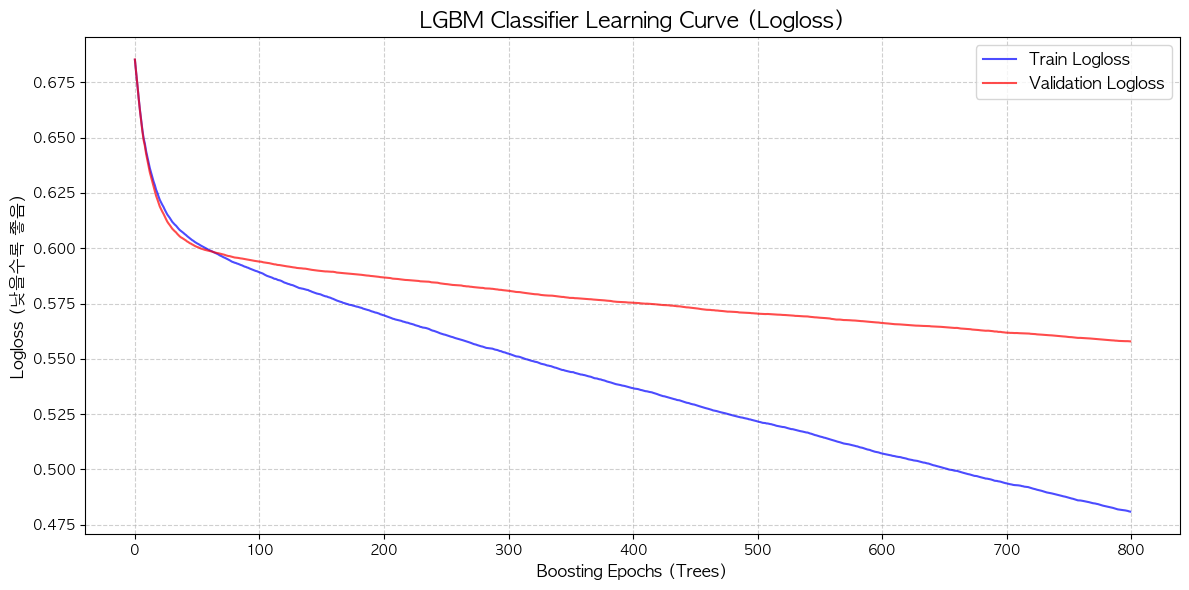

In [268]:
print(f"학습 자동 종료 완료! (최적의 트리 개수: {lgbm_model.best_iteration_})")

# 3. 러닝 커브 (Learning Curve) 시각화
plt.figure(figsize=(12, 6))

# LightGBM은 evals_result_ 에 학습 기록을 저장
results = lgbm_model.evals_result_
metric_name = list(results['Train'].keys())[0] 
epochs = len(results['Train'][metric_name])
x_axis = range(0, epochs)

# Train과 Valid의 Loss가 같이 떨어지다가, Valid가 다시 올라가는 시점이 과적합(Overfitting) 시작점입니다.
plt.plot(x_axis, results['Train'][metric_name], label='Train Logloss', color='blue', alpha=0.7)
plt.plot(x_axis, results['Validation'][metric_name], label='Validation Logloss', color='red', alpha=0.7)

plt.title("LGBM Classifier Learning Curve (Logloss)", fontsize=16)
plt.xlabel("Boosting Epochs (Trees)", fontsize=12)
plt.ylabel("Logloss (낮을수록 좋음)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [269]:
# 피처 중요도 확인

imp = pd.Series(
    lgbm_model.feature_importances_,
    index=actual_feature_names
).sort_values(ascending=False)

print(imp.head(50))

num__freight_value                              2037
num__delivery_price                             1925
num__freight_ratio                              1880
num__delivery_distance                          1849
num__price                                      1835
num__delivery_ratio                             1756
num__distance_km                                1686
num__delivery_speed                             1672
num__delay_days                                 1477
num__total_price                                1458
num__day_per_km                                 1392
num__expected_delivery_days                     1380
num__order_purchase_month                       1003
num__dispatch_days                               993
num__delivery_days                               970
num__approved_days                               342
num__order_item_id                               247
num__sp_route_type                               197
cat__order_purchase_dayofweek_tuesday         

### 2번째 분류모델: RandomForestClassifier

In [270]:
# # 1. 랜덤 포레스트 모델을 포함한 파이프라인 정의
# # (preprocessor는 이전에 ColumnTransformer로 정의한 객체를 그대로 재사용합니다)
# rf_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', RandomForestClassifier(
#         class_weight='balanced',
#         max_depth=15, 
#         min_samples_split=10, 
#         random_state=42,
#         n_estimators=200,
#         n_jobs=-1  # 병렬 처리를 위해 가용 CPU 코어 모두 사용
#     ))
# ])

In [271]:
# # 2. GridSearchCV를 위한 하이퍼파라미터 탐색 공간(Grid) 정의
# # 주의: 파이프라인 단계 이름('classifier')과 모델 파라미터 이름 사이에 언더바 2개(__) 연결
# rf_param_grid = {
#     'classifier__n_estimators': [100, 200, 300],  # 숲을 구성할 트리의 개수
#     'classifier__max_depth': [5, 10, 15],         # 트리의 최대 깊이
#     'classifier__min_samples_split': [2, 5, 10]   # 노드를 분할하기 위한 최소 데이터 수
# }

# # 3. GridSearchCV 객체 생성
# rf_grid_search = GridSearchCV(
#     estimator=rf_pipeline,
#     param_grid=rf_param_grid,
#     cv=3,                 # 3-Fold 교차 검증 수행
#     scoring='f1_macro',   # 불균형 데이터이므로 Macro F1 타겟
#     n_jobs=-1,            # 그리드 서치 자체의 병렬 처리
#     verbose=1             # 진행 상황 출력 (Scikit-learn의 기준에 맞춰 2 입력)
# )

# # 4. 파이프라인 학습 및 최적 파라미터 탐색
# # X_train은 인코딩되지 않은 원본 분할 상태여야 합니다.
# rf_grid_search.fit(X_train, y_train)

# # 5. 결과 확인 및 검증 데이터 예측
# print("Best Random Forest Parameters:", rf_grid_search.best_params_)
# print("Best Macro F1 Score:", rf_grid_search.best_score_)

# # 최적화된 파이프라인 객체로 예측 진행
# best_rf_pipeline = rf_grid_search.best_estimator_
# valid_proba_rf = best_rf_pipeline.predict_proba(X_valid)[:, 1]

# # Fitting 3 folds for each of 27 candidates, totalling 81 fits
# # Best Random Forest Parameters: {'classifier__max_depth': 15, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
# # Best Macro F1 Score: 0.6693442557674495

In [272]:
# # 5. 파이프라인 학습 (내부적으로 X_train만 전처리 규칙을 학습)
# rf_pipeline.fit(X_train, y_train)

# # 예측 시에는 파이프라인이 자동으로 X_valid를 변환 후 예측함
# valid_proba_rf = rf_pipeline.predict_proba(X_valid)[:, 1]

In [273]:
# # 0.01씩 threshold 바꿔가며 비교
# results = []

# for th in thresholds:
#     row = evaluate_threshold(y_valid, valid_proba_rf, th)
#     results.append(row)

# threshold_df = pd.DataFrame(results)

In [274]:
# # 시각화

# plt.figure(figsize=(10, 6))

# plt.plot(threshold_df["threshold"], threshold_df["neg_recall"], label="Negative Recall")
# plt.plot(threshold_df["threshold"], threshold_df["macro_f1"], label="Macro F1")
# plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
# plt.plot(threshold_df["threshold"], threshold_df["balanced_acc"], label="Balanced Accuracy")

# plt.xlabel("Threshold")
# plt.ylabel("Score")
# plt.title("Threshold Tuning Curve")
# plt.legend()
# plt.grid(True)
# plt.show()

In [275]:
# # neg_recall과 balanced_acc 차이
# threshold_df["gap"] = (threshold_df["neg_recall"] - threshold_df["balanced_acc"]).abs()

# # 두 값이 가장 가까운 threshold
# best_row = threshold_df.loc[threshold_df["gap"].idxmin()]
# best_threshold = best_row["threshold"]

# print("선택된 threshold:", best_threshold)
# print(best_row[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])

# # 선택된 threshold: 0.5999999999999998
# # threshold       0.600000
# # neg_recall      0.630215
# # balanced_acc    0.649619
# # macro_f1        0.606767
# # accuracy        0.660033
# # Name: 50, dtype: float64

In [276]:
# valid_pred = (valid_proba_rf >= best_threshold).astype(int)


# print("VALID ACC:", accuracy_score(y_valid, valid_pred))
# print("VALID Balanced ACC:", balanced_accuracy_score(y_valid, valid_pred))
# print("VALID Negative Recall:", recall_score(y_valid, valid_pred, pos_label=0))
# print("VALID F1(macro):", f1_score(y_valid, valid_pred, average='macro'))
# print("VALID F1(weighted):", f1_score(y_valid, valid_pred, average='weighted'))
# print(classification_report(y_valid, valid_pred, zero_division=0))
# print("VALID confusion matrix")
# print(confusion_matrix(y_valid, valid_pred))

### 3번째 분류모델: XGBoost Classifier

In [277]:
# # 1. XGBoost 파이프라인 정의
# # preprocessor는 앞서 ColumnTransformer로 만든 객체를 그대로 재사용합니다.
# xgb_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', XGBClassifier(
#         random_state=42,
#         n_jobs=-1,
#         # scale_pos_weight = (음성 데이터 수 / 양성 데이터 수)
#         # 예시: 음성이 10,000개, 양성이 30,000개라면 10000/30000 = 0.33을 입력합니다.
#         # scale_pos_weight=0.33, 
#         eval_metric='logloss', # XGBoost 최신 버전의 경고 방지
#         verbose=-1
#     ))
# ])

# # 2. 탐색할 하이퍼파라미터 그리드 정의
# # 파이프라인 단계 이름('classifier__')을 반드시 앞에 붙입니다.
# xgb_param_grid = {
#     'classifier__n_estimators': [200, 300, 500, 800, 1000],
#     'classifier__learning_rate': [0.01, 0.05],
#     'classifier__max_depth': [5, 7], 
#     'classifier__min_child_weight': [1, 3, 5], # 가지치기의 기준이 되는 가중치 합
#     'classifier__gamma': [0, 0.1, 0.5],        # 값이 클수록 보수적인 알고리즘(가지치기 강화)
# }

# # 3. GridSearchCV 객체 생성
# xgb_grid_search = GridSearchCV(
#     estimator=xgb_pipeline,
#     param_grid=xgb_param_grid,
#     cv=3,
#     scoring='f1_macro',
#     n_jobs=-1,
#     verbose=1 # 전체 진행률 출력을 위해 2 설정
# )

# # 4. 파이프라인 학습 및 최적 탐색
# # 주의: X_train은 원본 형태(인코딩/결측치 처리 전)여야 합니다.
# xgb_grid_search.fit(X_train, y_train)

# # 5. 결과 출력
# print("Best XGBoost Parameters:", xgb_grid_search.best_params_)
# print("Best Macro F1 Score:", xgb_grid_search.best_score_)

# # 최적 파이프라인으로 Valid 세트 예측
# best_xgb_pipeline = xgb_grid_search.best_estimator_
# valid_proba_xgb = best_xgb_pipeline.predict_proba(X_valid)[:, 1]

# # Fitting 3 folds for each of 180 candidates, totalling 540 fits
# # Best XGBoost Parameters: {'classifier__gamma': 0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 1000}
# # Best Macro F1 Score: 0.6604145105633888

In [278]:
# # 1. XGBoost 모델을 포함한 파이프라인 정의
# # (preprocessor는 이전에 ColumnTransformer로 정의한 객체를 그대로 재사용합니다)
# xgb_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', XGBClassifier(
#         max_depth=7, 
#         learning_rate=0.05,
#         min_child_weight=1,
#         random_state=42,
#         gamma=0,
#         n_estimators=1000,
#         n_jobs=-1,  # 병렬 처리를 위해 가용 CPU 코어 모두 사용
#         eval_metric='logloss',
#         early_stopping_rounds=30 # ★ 핵심: 30번 연속으로 Valid 점수가 안 오르면 자동 종료
#     ))
# ])

# # 5. 파이프라인 학습 (내부적으로 X_train만 전처리 규칙을 학습)
# xgb_pipeline.fit(X_train, y_train)

# # 예측 시에는 파이프라인이 자동으로 X_valid를 변환 후 예측함
# valid_proba_xgbm = xgb_pipeline.predict_proba(X_valid)[:, 1]

In [279]:
# # 1. 파이프라인 내부의 preprocessor만 단독으로 꺼내어 데이터를 직접 변환합니다.
# # (이 과정을 거쳐야만 에러 없는 X_valid_processed가 탄생합니다)
# X_train_processed = preprocessor.fit_transform(X_train)
# X_valid_processed = preprocessor.transform(X_valid)

# # 2. Pipeline이 아닌 순수 XGBClassifier 모델만 정의합니다.
# final_xgb_model = XGBClassifier(
#     max_depth=7, 
#     learning_rate=0.05,
#     min_child_weight=1,
#     random_state=42,
#     gamma=0,
#     n_estimators=1000,
#     n_jobs=-1,  
#     eval_metric='logloss',
#     early_stopping_rounds=30 
# )

# # 3. 직접 전처리한 두 데이터를 명확하게 모델에 주입합니다.
# # (메인 데이터와 eval_set 모두 숫자로만 이루어진 processed 상태이므로 완벽히 작동합니다)
# final_xgb_model.fit(
#     X_train_processed, 
#     y_train,
#     eval_set=[(X_valid_processed, y_valid)], 
#     verbose=0
# )

# # 예측 시에는 이미 직접 변환해 둔 X_valid_processed를 넣어야 합니다.
# valid_proba_xgbm = final_xgb_model.predict_proba(X_valid_processed)[:, 1]
# print(f"최적의 나무 개수(Best Iteration): {final_xgb_model.best_iteration}") 
# # 최적의 나무 개수(Best Iteration): 846

In [280]:
# # 0.01씩 threshold 바꿔가며 비교
# results = []

# for th in thresholds:
#     row = evaluate_threshold(y_valid, valid_proba_xgbm, th)
#     results.append(row)

# threshold_df = pd.DataFrame(results)

In [281]:
# # 시각화

# plt.figure(figsize=(10, 6))

# plt.plot(threshold_df["threshold"], threshold_df["neg_recall"], label="Negative Recall")
# plt.plot(threshold_df["threshold"], threshold_df["macro_f1"], label="Macro F1")
# plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
# plt.plot(threshold_df["threshold"], threshold_df["balanced_acc"], label="Balanced Accuracy")

# plt.xlabel("Threshold")
# plt.ylabel("Score")
# plt.title("Threshold Tuning Curve")
# plt.legend()
# plt.grid(True)
# plt.show()

In [282]:
# # neg_recall과 balanced_acc 차이
# threshold_df["gap"] = (threshold_df["neg_recall"] - threshold_df["balanced_acc"]).abs()

# # 두 값이 가장 가까운 threshold
# best_row = threshold_df.loc[threshold_df["gap"].idxmin()]
# best_threshold = best_row["threshold"]

# print("선택된 threshold:", best_threshold)
# print(best_row[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])

# # 선택된 threshold: 0.8099999999999996
# # threshold       0.810000
# # neg_recall      0.646754
# # balanced_acc    0.658112
# # macro_f1        0.612740
# # accuracy        0.664208
# # Name: 71, dtype: float64

In [283]:
# valid_pred = (valid_proba_xgbm >= best_threshold).astype(int)


# print("VALID ACC:", accuracy_score(y_valid, valid_pred))
# print("VALID Balanced ACC:", balanced_accuracy_score(y_valid, valid_pred))
# print("VALID Negative Recall:", recall_score(y_valid, valid_pred, pos_label=0))
# print("VALID F1(macro):", f1_score(y_valid, valid_pred, average='macro'))
# print("VALID F1(weighted):", f1_score(y_valid, valid_pred, average='weighted'))
# print(classification_report(y_valid, valid_pred, zero_division=0))
# print("VALID confusion matrix")
# print(confusion_matrix(y_valid, valid_pred))

### 분류모델 : LightGBM Classifier로 결정! (부정 recall이 가장 높음: 0.660)

TEST SET EVALUATION RESULTS (Pipeline Model)
TEST ACC: 0.6445
TEST Balanced ACC: 0.6505
TEST Negative Recall (Class 0): 0.6617
TEST F1 (macro): 0.5987
TEST F1 (weighted): 0.6714

[Classification Report]
              precision    recall  f1-score   support

           0       0.36      0.66      0.46      5064
           1       0.86      0.64      0.73     16795

    accuracy                           0.64     21859
   macro avg       0.61      0.65      0.60     21859
weighted avg       0.75      0.64      0.67     21859

[Confusion Matrix]
[[ 3351  1713]
 [ 6058 10737]]


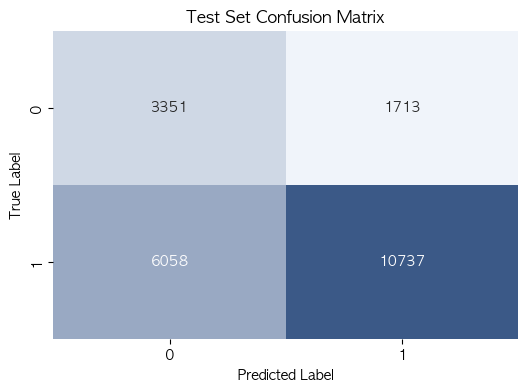

In [284]:
# 1. Test set 예측 (파이프라인을 사용하면 전처리와 예측이 튜닝 때와 완벽히 동일하게 진행됩니다)
test_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

# 2. Validation set에서 찾은 최적의 임계값(best_threshold) 적용
test_pred = (test_proba_lgbm >= best_threshold).astype(int)

# 3. Test set 결과 평가 및 출력
print("============================================================")
print("TEST SET EVALUATION RESULTS (Pipeline Model)")
print("============================================================")
print(f"TEST ACC: {accuracy_score(y_test, test_pred):.4f}")
print(f"TEST Balanced ACC: {balanced_accuracy_score(y_test, test_pred):.4f}")
print(f"TEST Negative Recall (Class 0): {recall_score(y_test, test_pred, pos_label=0):.4f}")
print(f"TEST F1 (macro): {f1_score(y_test, test_pred, average='macro'):.4f}")
print(f"TEST F1 (weighted): {f1_score(y_test, test_pred, average='weighted'):.4f}")

print("\n[Classification Report]")
print(classification_report(y_test, test_pred, zero_division=0))

print("[Confusion Matrix]")
print(confusion_matrix(y_test, test_pred))

# 시각화 - Confusion Matrix
blue_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue", ["#F0F4FA", "#3B5987"])

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d', cmap=blue_cmap, cbar=False)
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()